# SHA-256 TCT: 로컬 처리 vs 엣지 서버 오프로딩

같은 SHA-256 작업을 **로컬**에서 직접 처리할 때와 **엣지 서버**로 오프로딩할 때의 TCT(Task Completion Time)를 비교한다.

```
local (0.5 CPU) ──edge-server-net-1──▶ edge-server-1 (2 CPU)
                └─edge-server-net-2──▶ edge-server-2 (2 CPU)
```

| 실험 | 바꾸는 것 | 보는 것 |
|---|---|---|
| A | 연산량 (iter) | 작업 크기에 따른 로컬 처리 vs 엣지 서버 오프로딩 |
| B | 로컬↔엣지 서버 RTT | 로컬 처리가 더 나아지는 RTT (역전 지점) |
| C | 대역폭 (payload 256KB) | 전송량이 클 때 대역폭 영향 |
| D | 엣지 서버 CPU 부하 | 부하 걸린 엣지 서버 vs 한가한 엣지 서버 |
| E | 시나리오 `rtt-steps` | 시간에 따라 RTT가 바뀔 때 TCT 변화 |

준비: 이미지 `uvc-sha256:0.1`이 빌드되어 있어야 한다 (`docker build -t uvc-sha256:0.1 app`).
결과 CSV와 그림은 `results/`에 저장된다.

## 0. 준비

In [1]:
import io, os, re, subprocess, time
import pandas as pd
import matplotlib.pyplot as plt
from FogifySDK import FogifySDK

fogify = FogifySDK("http://controller:5000", "docker-compose.yaml")

SERVERS = {"edge-server-1": "http://edge-server-1:8080",
           "edge-server-2": "http://edge-server-2:8080"}
LOCAL_SIDE_DELAY_MS = 5   # 로컬 쪽 delay (compose 기본값). RTT = 로컬 쪽 + 엣지 서버 쪽
RESULTS = "results"
os.makedirs(RESULTS, exist_ok=True)

In [2]:
def container(label):
    """Fogify가 띄운 노드의 컨테이너 ID (예: 'local', 'edge-server-1')."""
    ids = subprocess.run(["docker", "ps", "-qf", f"name=fogify_{label}\\."],
                         capture_output=True, text=True, check=True).stdout.split()
    if not ids:
        raise RuntimeError(f"{label} 컨테이너가 없음. deploy 했는지 확인")
    return ids[0]


def client_cmd(mode, iter, n, servers, payload, label, interval):
    cmd = ["docker", "exec", container("local"), "uvc-client", "run",
           "-mode", mode, "-iter", str(iter), "-n", str(n), "-payload", str(payload),
           "-label", label, "-servers", ",".join(SERVERS[s] for s in servers)]
    if interval:
        cmd += ["-interval", interval]
    return cmd


def run_tasks(mode, iter=1_000_000, n=15, servers=("edge-server-1",), payload=1024, label="", interval=None):
    """로컬 노드에서 작업 n개를 실행하고 작업별 TCT를 DataFrame으로 반환."""
    out = subprocess.run(client_cmd(mode, iter, n, servers, payload, label, interval),
                         capture_output=True, text=True, check=True).stdout
    return pd.read_csv(io.StringIO(out))


def set_link(edge_server, rtt_ms=10, bandwidth="100Mbps"):
    """로컬↔엣지 서버 RTT와 대역폭 설정 (엣지 서버 쪽 delay = RTT - 로컬 쪽 delay)."""
    network = "edge-server-net-" + edge_server.rsplit("-", 1)[1]
    delay = max(rtt_ms - LOCAL_SIDE_DELAY_MS, 0)
    fogify.update_network(edge_server, network,
                          {"bidirectional": {"bandwidth": bandwidth, "latency": {"delay": f"{delay}ms"}}})
    time.sleep(2)


def ping_ms(edge_server, count=5):
    out = subprocess.run(["docker", "exec", container("local"), "ping", "-c", str(count), "-q", edge_server],
                         capture_output=True, text=True).stdout
    m = re.search(r"= [\d.]+/([\d.]+)/", out)
    return float(m.group(1)) if m else float("nan")


def summary(df, by):
    ok = df[df.status == "ok"]
    return ok.groupby(by).tct_ms.agg(median="median", p95=lambda s: s.quantile(0.95), n="count").round(2)

## 1. 배포

In [3]:
fogify.deploy(timeout=300)
time.sleep(3)
print("RTT edge-server-1:", ping_ms("edge-server-1"), "ms / edge-server-2:", ping_ms("edge-server-2"), "ms")

Deploy process: 100%|██████████| 3/3 [00:10<00:00,  3.36s/it]


RTT edge-server-1: 4.216 ms / edge-server-2: 11.552 ms


## 실험 A. 연산량(iter)에 따른 TCT

기본 RTT(약 10ms)에서 iter를 바꿔가며 로컬 처리와 엣지 서버 오프로딩을 비교한다.

In [4]:
rows = []
for it in [100_000, 1_000_000, 3_000_000]:
    rows.append(run_tasks("local", iter=it, label="A"))
    rows.append(run_tasks("edge-server", iter=it, label="A"))
A = pd.concat(rows)
A.to_csv(f"{RESULTS}/A_iter.csv", index=False)
summary(A, ["iter", "mode"])

median     p95   n
iter    mode                           
100000  edge-server   21.97   24.22  15
        local          5.98   58.72  15
1000000 edge-server   66.10   71.88  15
        local        114.07  168.70  15
3000000 edge-server  178.22  191.63  15
        local        393.90  400.56  15

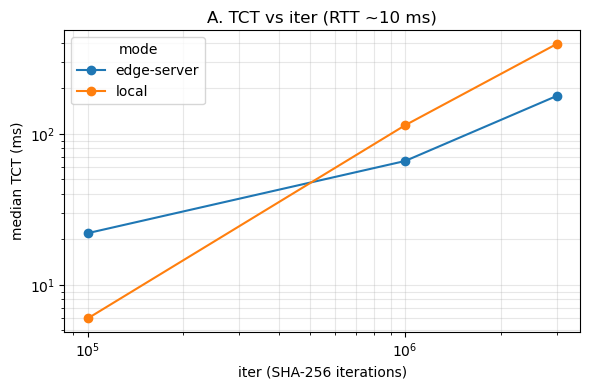

In [5]:
s = summary(A, ["iter", "mode"])["median"].unstack()
ax = s.plot(marker="o", logx=True, logy=True, figsize=(6, 4))
ax.set_xlabel("iter (SHA-256 iterations)"); ax.set_ylabel("median TCT (ms)")
ax.set_title("A. TCT vs iter (RTT ~10 ms)"); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{RESULTS}/A_iter.png", dpi=120); plt.show()

## 실험 B. RTT에 따른 TCT (역전 지점)

iter = 1M으로 고정하고, edge-server-1과의 RTT를 늘린다.
로컬 처리는 RTT와 관계없으므로 한 번만 측정해서 가로선으로 그린다.

In [6]:
RTTS = [10, 30, 55, 105, 205]
local_B = run_tasks("local", iter=1_000_000, label="B")
rows, measured = [local_B], {}
for rtt in RTTS:
    set_link("edge-server-1", rtt_ms=rtt)
    measured[rtt] = ping_ms("edge-server-1")
    df = run_tasks("edge-server", iter=1_000_000, label="B")
    df["rtt_target_ms"] = rtt
    rows.append(df)
set_link("edge-server-1", rtt_ms=10)   # 원래대로

B = pd.concat(rows)
B.to_csv(f"{RESULTS}/B_rtt.csv", index=False)
print("목표 RTT -> ping 실측:", measured)
summary(B[B["mode"] == "edge-server"], ["rtt_target_ms"]).assign(local_median=local_B.tct_ms.median())

목표 RTT -> ping 실측: {10: 10.256, 30: 30.488, 55: 55.356, 105: 105.584, 205: 205.521}


,median,p95,n,local_median
rtt_target_ms,,,,
10.0,66.42,70.97,15,114.409
30.0,89.75,93.77,15,114.409
55.0,113.44,117.93,15,114.409
105.0,166.66,169.46,15,114.409
205.0,265.43,271.87,15,114.409


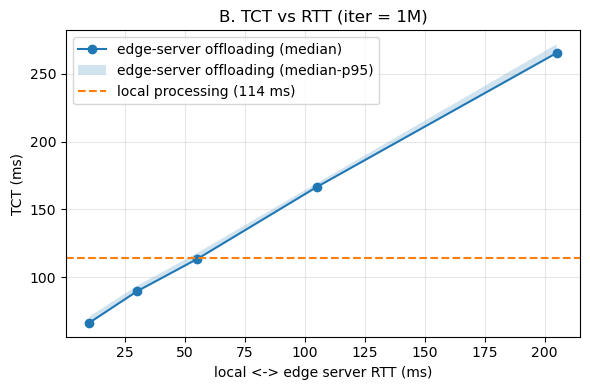

엣지 서버 계산 시간 중앙값 58.7 ms -> 역전 RTT 추정 ≈ 56 ms


In [7]:
es = summary(B[B["mode"] == "edge-server"], ["rtt_target_ms"])
local_med = local_B.tct_ms.median()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(es.index, es["median"], marker="o", label="edge-server offloading (median)")
ax.fill_between(es.index, es["median"], es["p95"], alpha=0.2, label="edge-server offloading (median-p95)")
ax.axhline(local_med, color="C1", ls="--", label=f"local processing ({local_med:.0f} ms)")
ax.set_xlabel("local <-> edge server RTT (ms)"); ax.set_ylabel("TCT (ms)")
ax.set_title("B. TCT vs RTT (iter = 1M)"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS}/B_rtt.png", dpi=120); plt.show()

# 엣지 서버 TCT ≈ 계산 시간 + RTT 이므로, 로컬 TCT와 같아지는 RTT를 직선으로 추정
compute_med = B[B["mode"] == "edge-server"].server_compute_ms.median()
print(f"엣지 서버 계산 시간 중앙값 {compute_med:.1f} ms -> 역전 RTT 추정 ≈ {local_med - compute_med:.0f} ms")

## 실험 C. 대역폭에 따른 TCT

payload를 256KB로 키우고 edge-server-1 쪽 대역폭을 줄인다 (RTT ≈ 10ms 유지).

In [8]:
PAYLOAD = 256 * 1024
rows = [run_tasks("local", iter=1_000_000, n=5, payload=PAYLOAD, label="C")]
for bw in ["100Mbps", "10Mbps", "1Mbps"]:
    set_link("edge-server-1", rtt_ms=10, bandwidth=bw)
    df = run_tasks("edge-server", iter=1_000_000, n=5, payload=PAYLOAD, label="C")
    df["bandwidth"] = bw
    rows.append(df)
set_link("edge-server-1", rtt_ms=10, bandwidth="100Mbps")

C = pd.concat(rows)
C.to_csv(f"{RESULTS}/C_bw.csv", index=False)
summary(C.fillna({"bandwidth": "(로컬 처리)"}), ["bandwidth"])

,median,p95,n
bandwidth,,,
(로컬 처리),112.63,155.08,5
100Mbps,68.69,74.42,5
10Mbps,97.09,101.15,5
1Mbps,344.46,350.58,5


## 실험 D. 엣지 서버 CPU 부하

edge-server-1에 CPU 부하 80%를 60초 동안 걸고, 그동안 edge-server-1과 edge-server-2(한가함)로 각각 오프로딩한다.

In [9]:
before = pd.concat([run_tasks("edge-server", servers=("edge-server-1",), label="D-before"),
                    run_tasks("edge-server", servers=("edge-server-2",), label="D-before")])
fogify.stress("edge-server-1", duration=60, cpu=80)
time.sleep(3)
during = pd.concat([run_tasks("edge-server", servers=("edge-server-1",), label="D-stress"),
                    run_tasks("edge-server", servers=("edge-server-2",), label="D-stress")])
D = pd.concat([before, during])
D.to_csv(f"{RESULTS}/D_stress.csv", index=False)

ok = D[D.status == "ok"]
ok.groupby(["label", "target"])[["tct_ms", "server_compute_ms"]].median().round(1)

tct_ms  server_compute_ms
label    target                                              
D-before http://edge-server-1:8080    66.1               55.1
         http://edge-server-2:8080    66.0               55.2
D-stress http://edge-server-1:8080    93.6               83.1
         http://edge-server-2:8080    76.2               65.7

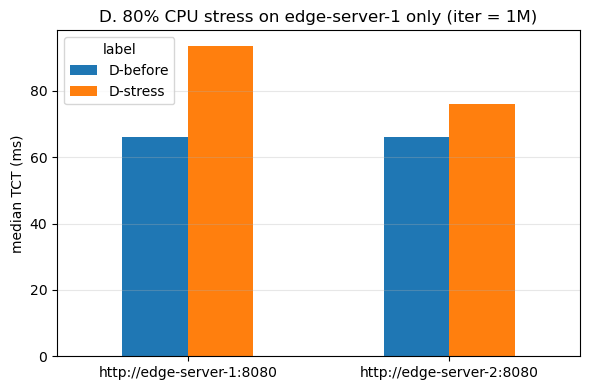

In [10]:
t = ok.groupby(["target", "label"]).tct_ms.median().unstack()
ax = t.plot.bar(figsize=(6, 4), rot=0)
ax.set_xlabel(""); ax.set_ylabel("median TCT (ms)")
ax.set_title("D. 80% CPU stress on edge-server-1 only (iter = 1M)"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{RESULTS}/D_stress.png", dpi=120); plt.show()
time.sleep(max(0, 60 - 20))   # stress가 끝날 때까지 대기

## 실험 E. 시나리오 `rtt-steps` 동안의 TCT

엣지 서버 오프로딩 작업을 계속 보내면서 compose에 정의한 시나리오를 실행한다.
시나리오는 30초마다 edge-server-1의 RTT를 30 → 55 → 105 → 10ms로 바꾼다.

100%|██████████| 120/120 [02:00<00:00,  1.01s/it]


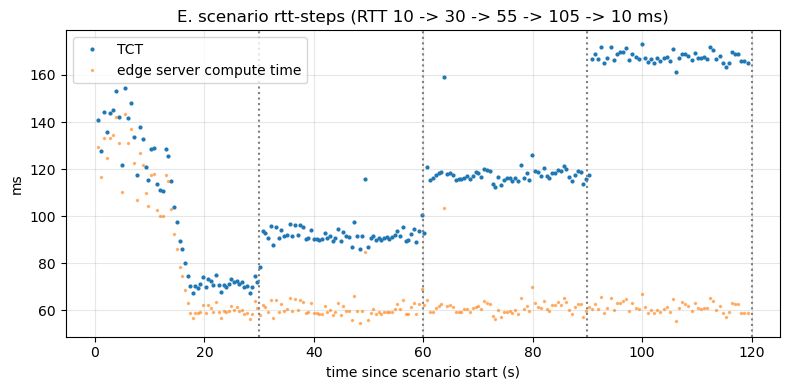

In [11]:
proc = subprocess.Popen(client_cmd("edge-server", 1_000_000, 230, ("edge-server-1",), 1024, "E", "400ms"),
                        stdout=subprocess.PIPE, text=True)
t0, t1 = fogify.scenario_execution("rtt-steps", remove_previous_metrics=False)
E = pd.read_csv(io.StringIO(proc.communicate()[0]))
E.to_csv(f"{RESULTS}/E_scenario.csv", index=False)

E["t_s"] = (E.ts_unix_ms - t0.timestamp() * 1000) / 1000
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(E.t_s, E.tct_ms, ".", ms=4, label="TCT")
ax.plot(E.t_s, E.server_compute_ms, ".", ms=3, alpha=0.5, label="edge server compute time")
for x in [30, 60, 90, 120]:
    ax.axvline(x, color="gray", ls=":")
ax.set_xlabel("time since scenario start (s)"); ax.set_ylabel("ms")
ax.set_title("E. scenario rtt-steps (RTT 10 -> 30 -> 55 -> 105 -> 10 ms)"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS}/E_scenario.png", dpi=120); plt.show()

## 정리: undeploy

In [12]:
fogify.undeploy()

Undeploy process: 100%|██████████| 3/3 [00:05<00:00,  1.67s/it]


{'message': 'The 3 services are undeployed'}